<a href="https://colab.research.google.com/github/alamin35bcs/COCO-2017/blob/main/Project_DL_AMR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
zip_path = "/content/drive/MyDrive/AMR_DATASET.zip"
extract_path = "/content/AMR_DATASET"

In [8]:
import zipfile
import os

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

AMR_DATASET/
    images/
        1-HQ-2022x04x18-15_58_15.jpg
        1-HQ-2023x5x31-13_2_41.jpg
        404-HQ-2022x6x1-10_43_40.jpg
        1-HQ-2023x6x2-15_38_9.jpg
        1-HQ-2023x6x2-12_11_43.jpg
    supplementary/
        data_file.json
        definitions.json
        labels/
            2023_10_26T08_31_28Z-robot19-hq.png
            404-HQ-2022x6x1-10_46_22.png
            2023_10_26T09_51_56Z-robot19-hq.png
            2023_10_26T07_38_21Z-robot19-hq.png
            2024_01_19T09_25_23Z-robot6-hq.png
    train/
        data_file.json
        definitions.json
        labels/
            1-HQ-2023x06x09-13_38_40.png
            1-HQ-2023x05x23-12_54_15.png
            2023_10_05T11_40_57Z-robot6-hq.png
            404-HQ-2022x6x1-11_1_21.png
            8-HQ-2023x12x26-17_9_54.png
    test/
        data_file.json
        definitions.json
        labels/
            1-HQ-2022x04x12-16_06_10.png
            404-HQ-2022x6x1-10_40_3.png
            404-HQ-2022x6x1-10_53_29.png
  

In [10]:
from glob import glob

jpg_files = glob(extract_path + "/**/*.jpg", recursive=True)
png_files = glob(extract_path + "/**/*.png", recursive=True)
json_files = glob(extract_path + "/**/*.json", recursive=True)

print("JPG images:", len(jpg_files))
print("PNG images:", len(png_files))
print("JSON files:", len(json_files))

print("\nFirst 5 image files:")
for f in jpg_files[:5]:
    print(f)

JPG images: 9795
PNG images: 9795
JSON files: 6

First 5 image files:
/content/AMR_DATASET/images/1-HQ-2022x04x18-15_58_15.jpg
/content/AMR_DATASET/images/1-HQ-2023x5x31-13_2_41.jpg
/content/AMR_DATASET/images/404-HQ-2022x6x1-10_43_40.jpg
/content/AMR_DATASET/images/1-HQ-2023x6x2-15_38_9.jpg
/content/AMR_DATASET/images/1-HQ-2023x6x2-12_11_43.jpg


Image size: (1280, 480)


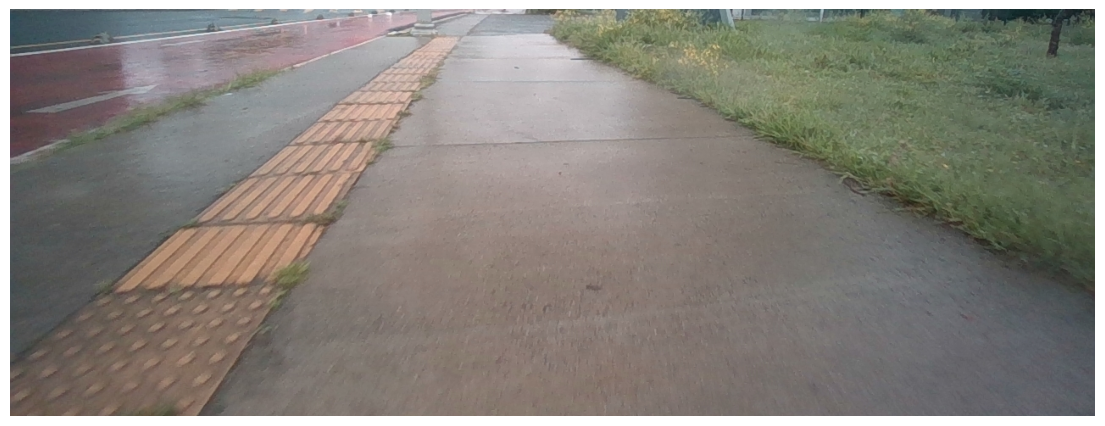

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = jpg_files[0]

img = Image.open(img_path)
print("Image size:", img.size)

plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
import json

sample_json = json_files[0]

with open(sample_json, "r") as f:
    data = json.load(f)

print("JSON file:", sample_json)
print("Type:", type(data))

if isinstance(data, dict):
    print("Keys:", data.keys())

print(json.dumps(data, indent=2)[:2000])

JSON file: /content/AMR_DATASET/supplementary/data_file.json
Type: <class 'dict'>
Keys: dict_keys(['datafile_entries'])
{
  "datafile_entries": [
    {
      "data_entry": {
        "data_version_id": "",
        "data_metadata": {
          "latitude": 41.107475126463434,
          "longitude": 29.027348756790165,
          "waypoint_id": 520,
          "tags": [
            "Cloudy"
          ],
          "width": 1280,
          "height": 720
        }
      },
      "label_entry": {
        "project_id": 145,
        "label_id": "63f762a1bc4d9e2755225aa5",
        "label_version_id": 30102411333528,
        "label_data": [
          {
            "label_class": "Road",
            "labeling_result": "1.7066666666666666,245.6872037914692 109.22666666666666,242.27488151658767 276.4800000000001,233.74407582938397 361.81333333333345,225.21327014218008 365.2266666666667,308.81516587677726 6.826666666666666,458.9573459715638"
          },
          {
            "label_class": "Road",
  

In [13]:
import json
import os

train_json = "/content/AMR_DATASET/train/data_file.json"

with open(train_json, "r") as f:
    train_data = json.load(f)

print(type(train_data))
print(train_data.keys())
print("Number of entries:", len(train_data["datafile_entries"]))

first_entry = train_data["datafile_entries"][0]
print(first_entry.keys())

print(json.dumps(first_entry, indent=2)[:3000])

<class 'dict'>
dict_keys(['datafile_entries'])
Number of entries: 8539
dict_keys(['data_entry', 'label_entry', 'tags'])
{
  "data_entry": {
    "data_version_id": "",
    "data_metadata": {
      "latitude": 41.107770189532786,
      "longitude": 29.027270972728733,
      "waypoint_id": 524,
      "tags": [
        "Normal"
      ],
      "width": 1280,
      "height": 720
    }
  },
  "label_entry": {
    "project_id": 17,
    "label_id": "64f707ba34624da9c05f99c4",
    "label_version_id": 30102411333767,
    "label_data": [
      {
        "label_class": "Road",
        "labeling_result": "646.8266666666666,221.80094786729865 645.12,278.10426540284357 1276.5866666666668,532.3222748815165 1280.0,211.563981042654"
      },
      {
        "label_class": "Sidewalk",
        "labeling_result": "0.0,491.3744075829384 1.7066666666666666,718.2938388625593 1278.2933333333333,720.0 1278.2933333333333,547.6777251184832 651.9466666666666,291.75355450236964 646.8266666666666,310.521327014218 641

In [14]:
import json

first_entry = train_data["datafile_entries"][0]

print(json.dumps(first_entry, indent=2))

{
  "data_entry": {
    "data_version_id": "",
    "data_metadata": {
      "latitude": 41.107770189532786,
      "longitude": 29.027270972728733,
      "waypoint_id": 524,
      "tags": [
        "Normal"
      ],
      "width": 1280,
      "height": 720
    }
  },
  "label_entry": {
    "project_id": 17,
    "label_id": "64f707ba34624da9c05f99c4",
    "label_version_id": 30102411333767,
    "label_data": [
      {
        "label_class": "Road",
        "labeling_result": "646.8266666666666,221.80094786729865 645.12,278.10426540284357 1276.5866666666668,532.3222748815165 1280.0,211.563981042654"
      },
      {
        "label_class": "Sidewalk",
        "labeling_result": "0.0,491.3744075829384 1.7066666666666666,718.2938388625593 1278.2933333333333,720.0 1278.2933333333333,547.6777251184832 651.9466666666666,291.75355450236964 646.8266666666666,310.521327014218 641.7066666666667,330.99526066350717 648.5333333333333,353.17535545023696 653.6533333333333,377.06161137440756 622.93333333

In [15]:
definitions_path = "/content/AMR_DATASET/train/definitions.json"

with open(definitions_path, "r") as f:
    definitions = json.load(f)

print(json.dumps(definitions, indent=2)[:5000])

{
  "id": "67763ff259765469a95e8592",
  "metadata": {
    "name": "ITU-V7-DEV-V2",
    "labeling_type_id": 1,
    "description": "ITU V7 Dev V2",
    "tags": [
      "Normal",
      "Cloudy",
      "Rainy",
      "Traffic",
      "Sunny",
      "Motion Blur",
      "Crowd",
      "Tilt Over",
      "Sunburst",
      "Sunburst-Labeled",
      "Off-road",
      "Non-Driveable",
      "Sunburst-Not-Labeled",
      "Road Damage",
      "Night Time",
      "ITU"
    ],
    "is_locked": true,
    "created_at": "2025-01-02T07:27:46.525Z",
    "updated_at": "2025-01-02T07:34:00.098Z"
  },
  "class_mapping": {
    "Road": 1,
    "Sidewalk": 2,
    "Cycle_Path": 3,
    "Other": 0
  },
  "class_weights": {
    "1": 0.6008,
    "2": 1.5892,
    "3": 0.6686,
    "0": 4.7394
  },
  "rgb_means": [
    0.5326894501187102,
    0.5273085599375552,
    0.5228899329925728
  ],
  "rgb_stds": [
    0.22562493108979817,
    0.19994216940775636,
    0.20289841272246267
  ],
  "top_pixel_cut": 240,
  "dataset_

In [16]:
from glob import glob
import os

label_files = glob("/content/AMR_DATASET/train/labels/**/*", recursive=True)
label_files = [f for f in label_files if os.path.isfile(f)]

print("Number of label files:", len(label_files))

for f in label_files[:20]:
    print(f)

Number of label files: 8539
/content/AMR_DATASET/train/labels/1-HQ-2023x06x09-13_38_40.png
/content/AMR_DATASET/train/labels/1-HQ-2023x05x23-12_54_15.png
/content/AMR_DATASET/train/labels/2023_10_05T11_40_57Z-robot6-hq.png
/content/AMR_DATASET/train/labels/404-HQ-2022x6x1-11_1_21.png
/content/AMR_DATASET/train/labels/8-HQ-2023x12x26-17_9_54.png
/content/AMR_DATASET/train/labels/2024_01_26T13_48_47Z-robot17-hq.png
/content/AMR_DATASET/train/labels/2023_10_30T08_46_38Z-robot19-hq.png
/content/AMR_DATASET/train/labels/2023_10_06T13_17_08Z-robot6-hq.png
/content/AMR_DATASET/train/labels/2024_01_12T14_15_36Z-robot19-hq.png
/content/AMR_DATASET/train/labels/1-HQ-2023x09x13-11_32_13.png
/content/AMR_DATASET/train/labels/1-HQ-2023x6x2-15_30_46.png
/content/AMR_DATASET/train/labels/2023_10_17T10_52_09Z-robot1-hq.png
/content/AMR_DATASET/train/labels/2024_01_17T11_11_03Z-robot10-hq.png
/content/AMR_DATASET/train/labels/1-HQ-2023x09x07-12_19_41.png
/content/AMR_DATASET/train/labels/8-HQ-2023x12x2

In [17]:
image_files = glob("/content/AMR_DATASET/images/**/*.jpg", recursive=True)

print("Number of image files:", len(image_files))

for f in image_files[:20]:
    print(f)

Number of image files: 9795
/content/AMR_DATASET/images/1-HQ-2022x04x18-15_58_15.jpg
/content/AMR_DATASET/images/1-HQ-2023x5x31-13_2_41.jpg
/content/AMR_DATASET/images/404-HQ-2022x6x1-10_43_40.jpg
/content/AMR_DATASET/images/1-HQ-2023x6x2-15_38_9.jpg
/content/AMR_DATASET/images/1-HQ-2023x6x2-12_11_43.jpg
/content/AMR_DATASET/images/1-HQ-2023x5x31-13_25_22.jpg
/content/AMR_DATASET/images/404-HQ-2022x6x1-10_35_18.jpg
/content/AMR_DATASET/images/8-HQ-2023x12x29-16_44_08.jpg
/content/AMR_DATASET/images/2023_10_08T12_31_09Z-robot1-hq.jpg
/content/AMR_DATASET/images/2023_10_11T12_04_04Z-robot10-hq.jpg
/content/AMR_DATASET/images/404-HQ-2022x6x1-10_34_26.jpg
/content/AMR_DATASET/images/6-HQ-2023x05x02-07_06_15.jpg
/content/AMR_DATASET/images/2023_10_17T10_52_09Z-robot1-hq.jpg
/content/AMR_DATASET/images/2024_01_16T13_23_19Z-robot19-hq.jpg
/content/AMR_DATASET/images/1-HQ-2023x06x09-13_41_07.jpg
/content/AMR_DATASET/images/404-HQ-2022x6x1-10_38_45.jpg
/content/AMR_DATASET/images/2023_11_11T08_

In [18]:
from glob import glob
import os

label_files = glob("/content/AMR_DATASET/train/labels/**/*", recursive=True)
label_files = [f for f in label_files if os.path.isfile(f)]

print("Number of label files:", len(label_files))

for f in label_files[:20]:
    print(f)

Number of label files: 8539
/content/AMR_DATASET/train/labels/1-HQ-2023x06x09-13_38_40.png
/content/AMR_DATASET/train/labels/1-HQ-2023x05x23-12_54_15.png
/content/AMR_DATASET/train/labels/2023_10_05T11_40_57Z-robot6-hq.png
/content/AMR_DATASET/train/labels/404-HQ-2022x6x1-11_1_21.png
/content/AMR_DATASET/train/labels/8-HQ-2023x12x26-17_9_54.png
/content/AMR_DATASET/train/labels/2024_01_26T13_48_47Z-robot17-hq.png
/content/AMR_DATASET/train/labels/2023_10_30T08_46_38Z-robot19-hq.png
/content/AMR_DATASET/train/labels/2023_10_06T13_17_08Z-robot6-hq.png
/content/AMR_DATASET/train/labels/2024_01_12T14_15_36Z-robot19-hq.png
/content/AMR_DATASET/train/labels/1-HQ-2023x09x13-11_32_13.png
/content/AMR_DATASET/train/labels/1-HQ-2023x6x2-15_30_46.png
/content/AMR_DATASET/train/labels/2023_10_17T10_52_09Z-robot1-hq.png
/content/AMR_DATASET/train/labels/2024_01_17T11_11_03Z-robot10-hq.png
/content/AMR_DATASET/train/labels/1-HQ-2023x09x07-12_19_41.png
/content/AMR_DATASET/train/labels/8-HQ-2023x12x2

In [19]:
extensions = {}

for f in label_files:
    ext = os.path.splitext(f)[1]
    extensions[ext] = extensions.get(ext, 0) + 1

print(extensions)

{'.png': 8539}


Label path: /content/AMR_DATASET/train/labels/1-HQ-2023x06x09-13_38_40.png
Mask size: (1280, 480)
Mask mode: L


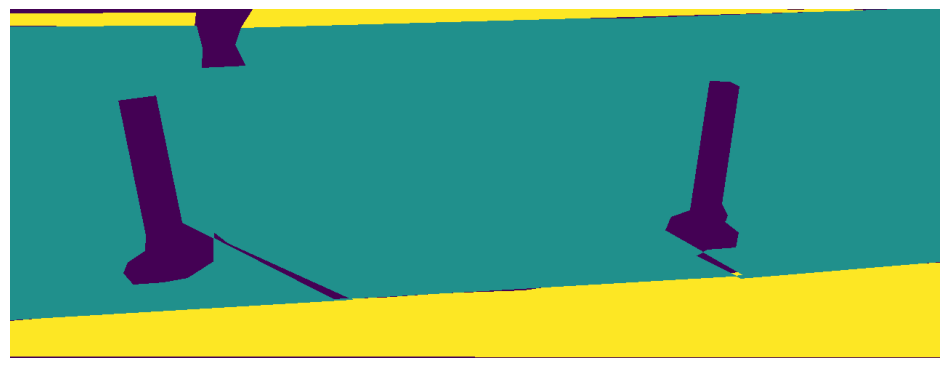

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

label_path = label_files[0]

mask = Image.open(label_path)
print("Label path:", label_path)
print("Mask size:", mask.size)
print("Mask mode:", mask.mode)

plt.figure(figsize=(12, 5))
plt.imshow(mask)
plt.axis("off")
plt.show()

In [21]:
import os
import json
import random
import numpy as np
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import fcn_resnet50

import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [24]:
import os
import json
import random
import numpy as np
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import fcn_resnet50

import matplotlib.pyplot as plt
from tqdm import tqdm

In [25]:
ROOT = "/content/AMR_DATASET"
IMAGE_DIR = os.path.join(ROOT, "images")
TRAIN_LABEL_DIR = os.path.join(ROOT, "train", "labels")
TEST_LABEL_DIR = os.path.join(ROOT, "test", "labels")

In [26]:
from glob import glob
import os

image_files = sorted(glob(IMAGE_DIR + "/**/*.jpg", recursive=True))
train_mask_files = sorted(glob(TRAIN_LABEL_DIR + "/**/*.png", recursive=True))
test_mask_files = sorted(glob(TEST_LABEL_DIR + "/**/*.png", recursive=True))

print("Image folder exists:", os.path.exists(IMAGE_DIR))
print("Train label folder exists:", os.path.exists(TRAIN_LABEL_DIR))
print("Test label folder exists:", os.path.exists(TEST_LABEL_DIR))

print("Total images:", len(image_files))
print("Train masks:", len(train_mask_files))
print("Test masks:", len(test_mask_files))

print("\nSample image:", image_files[0] if len(image_files) > 0 else "No image found")
print("Sample train mask:", train_mask_files[0] if len(train_mask_files) > 0 else "No train mask found")
print("Sample test mask:", test_mask_files[0] if len(test_mask_files) > 0 else "No test mask found")

Image folder exists: True
Train label folder exists: True
Test label folder exists: True
Total images: 9795
Train masks: 8539
Test masks: 687

Sample image: /content/AMR_DATASET/images/0-HQ-2022x9x30-14_52_36.jpg
Sample train mask: /content/AMR_DATASET/train/labels/0-HQ-2022x9x30-14_52_36.png
Sample test mask: /content/AMR_DATASET/test/labels/0-HQ-2022x9x30-14_58_58.png


In [27]:
import os
import random

image_dict = {}

for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]
    image_dict[base] = img_path

def match_image_mask(mask_files):
    pairs = []

    for mask_path in mask_files:
        base = os.path.splitext(os.path.basename(mask_path))[0]

        if base in image_dict:
            pairs.append((image_dict[base], mask_path))

    return pairs

train_pairs = match_image_mask(train_mask_files)
test_pairs = match_image_mask(test_mask_files)

print("Matched train pairs:", len(train_pairs))
print("Matched test pairs:", len(test_pairs))

print("\nExample train pair:")
print(train_pairs[0])

Matched train pairs: 8539
Matched test pairs: 687

Example train pair:
('/content/AMR_DATASET/images/0-HQ-2022x9x30-14_52_36.jpg', '/content/AMR_DATASET/train/labels/0-HQ-2022x9x30-14_52_36.png')


In [28]:
random.seed(42)
random.shuffle(train_pairs)

val_ratio = 0.15
val_size = int(len(train_pairs) * val_ratio)

val_pairs = train_pairs[:val_size]
train_pairs = train_pairs[val_size:]

print("Final train samples:", len(train_pairs))
print("Validation samples:", len(val_pairs))
print("Test samples:", len(test_pairs))

Final train samples: 7259
Validation samples: 1280
Test samples: 687


In [29]:
import numpy as np
from PIL import Image

unique_values = set()

for mask_path in train_mask_files[:500]:
    mask = np.array(Image.open(mask_path))
    unique_values.update(np.unique(mask).tolist())

unique_values = sorted(list(unique_values))

print("Unique mask values:", unique_values)
print("Number of classes found:", len(unique_values))

NUM_CLASSES = max(unique_values) + 1
print("NUM_CLASSES =", NUM_CLASSES)

Unique mask values: [0, 1, 2, 3]
Number of classes found: 4
NUM_CLASSES = 4


In [31]:
NUM_CLASSES = 4

In [33]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=4):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bottleneck = self.bottleneck(p4)

        u4 = self.up4(bottleneck)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final_conv(u1)

In [36]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF

class AMRSegmentationDataset(Dataset):
    def __init__(self, pairs, image_size=(192, 512)):
        self.pairs = pairs
        self.image_size = image_size  # height, width

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(image, self.image_size)
        mask = TF.resize(mask, self.image_size, interpolation=Image.NEAREST)

        image = TF.to_tensor(image)
        mask = torch.from_numpy(np.array(mask)).long()

        return image, mask

print("AMRSegmentationDataset class created successfully.")

AMRSegmentationDataset class created successfully.


In [37]:
BATCH_SIZE = 4

train_dataset = AMRSegmentationDataset(train_pairs)
val_dataset = AMRSegmentationDataset(val_pairs)
test_dataset = AMRSegmentationDataset(test_pairs)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

sample_images, sample_masks = next(iter(train_loader))

print("DataLoaders created successfully!")
print("Image batch shape:", sample_images.shape)
print("Mask batch shape:", sample_masks.shape)
print("Mask min:", sample_masks.min().item())
print("Mask max:", sample_masks.max().item())

DataLoaders created successfully!
Image batch shape: torch.Size([4, 3, 192, 512])
Mask batch shape: torch.Size([4, 192, 512])
Mask min: 0
Mask max: 3


In [38]:
unet_model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)

sample_images, sample_masks = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    sample_outputs = unet_model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Mask shape:", sample_masks.shape)

Input shape: torch.Size([4, 3, 192, 512])
Output shape: torch.Size([4, 4, 192, 512])
Mask shape: torch.Size([4, 192, 512])


In [40]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(unet_model.parameters(), lr=1e-4)

def pixel_accuracy(outputs, masks):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == masks).float()
    return correct.sum() / correct.numel()

def mean_iou(outputs, masks, num_classes):
    preds = torch.argmax(outputs, dim=1)
    ious = []

    for cls in range(num_classes):
        pred_cls = preds == cls
        mask_cls = masks == cls

        intersection = (pred_cls & mask_cls).sum().float()
        union = (pred_cls | mask_cls).sum().float()

        if union == 0:
            continue

        ious.append((intersection / union).item())

    if len(ious) == 0:
        return 0.0

    return sum(ious) / len(ious)

In [41]:
EPOCHS = 5

unet_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    unet_model.train()
    train_loss = 0
    train_acc = 0
    train_iou = 0

    for images, masks in tqdm(train_loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = unet_model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += pixel_accuracy(outputs, masks).item()
        train_iou += mean_iou(outputs, masks, NUM_CLASSES)

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_iou /= len(train_loader)

    unet_model.eval()
    val_loss = 0
    val_acc = 0
    val_iou = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = unet_model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_acc += pixel_accuracy(outputs, masks).item()
            val_iou += mean_iou(outputs, masks, NUM_CLASSES)

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    val_iou /= len(val_loader)

    unet_history["train_loss"].append(train_loss)
    unet_history["val_loss"].append(val_loss)
    unet_history["train_acc"].append(train_acc)
    unet_history["val_acc"].append(val_acc)
    unet_history["train_iou"].append(train_iou)
    unet_history["val_iou"].append(val_iou)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train mIoU: {train_iou:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val mIoU:   {val_iou:.4f}")


Epoch [1/5]


100%|██████████| 320/320 [00:49<00:00,  6.41it/s]


Train Loss: 0.8221 | Train Acc: 0.6897 | Train mIoU: 0.3976
Val Loss:   0.7073 | Val Acc:   0.7258 | Val mIoU:   0.4571

Epoch [2/5]


100%|██████████| 320/320 [00:50<00:00,  6.38it/s]


Train Loss: 0.6973 | Train Acc: 0.7342 | Train mIoU: 0.4597
Val Loss:   0.6154 | Val Acc:   0.7670 | Val mIoU:   0.4947

Epoch [3/5]


...

Train Loss: 0.6264 | Train Acc: 0.7642 | Train mIoU: 0.4987
Val Loss:   0.5603 | Val Acc:   0.7868 | Val mIoU:   0.5199

Epoch [4/5]


100%|██████████| 320/320 [00:50<00:00,  6.35it/s]


Train Loss: 0.5674 | Train Acc: 0.7856 | Train mIoU: 0.5386
Val Loss:   0.5038 | Val Acc:   0.8101 | Val mIoU:   0.5543

Epoch [5/5]


100%|██████████| 320/320 [00:50<00:00,  6.37it/s]

Train Loss: 0.5142 | Train Acc: 0.8100 | Train mIoU: 0.5814
Val Loss:   0.4676 | Val Acc:   0.8274 | Val mIoU:   0.5762


In [42]:
torch.save(unet_model.state_dict(), "/content/unet_amr_segmentation.pth")
print("U-Net model saved.")

U-Net model saved.


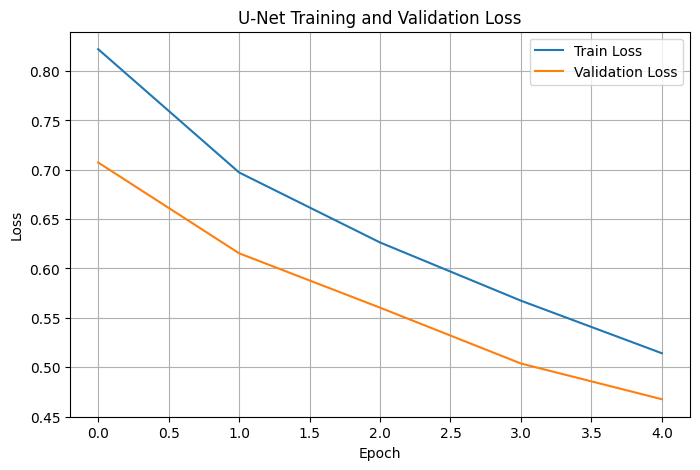

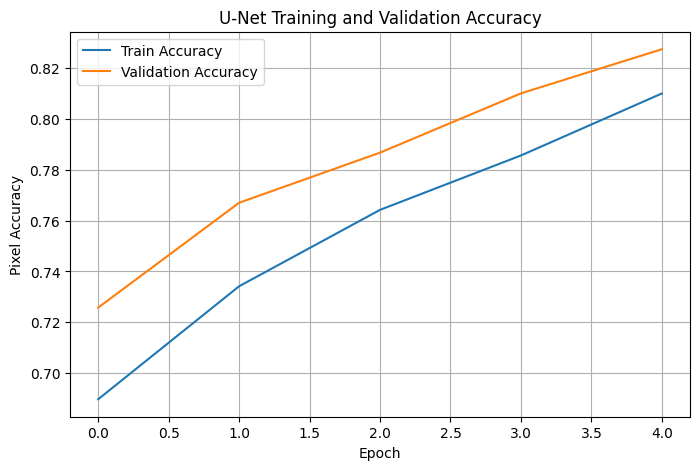

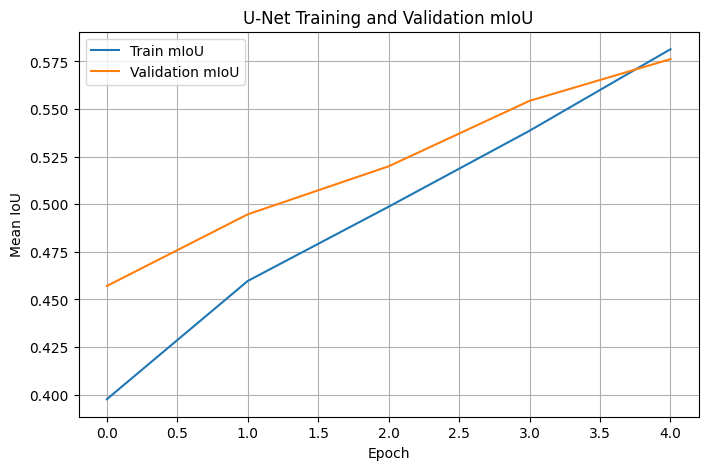

In [43]:
plt.figure(figsize=(8,5))
plt.plot(unet_history["train_loss"], label="Train Loss")
plt.plot(unet_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(unet_history["train_acc"], label="Train Accuracy")
plt.plot(unet_history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Pixel Accuracy")
plt.title("U-Net Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(unet_history["train_iou"], label="Train mIoU")
plt.plot(unet_history["val_iou"], label="Validation mIoU")
plt.xlabel("Epoch")
plt.ylabel("Mean IoU")
plt.title("U-Net Training and Validation mIoU")
plt.legend()
plt.grid(True)
plt.show()

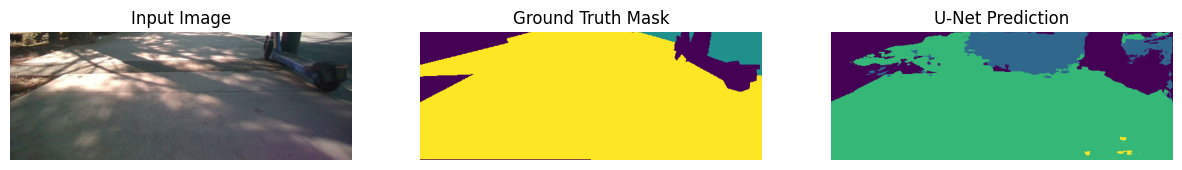

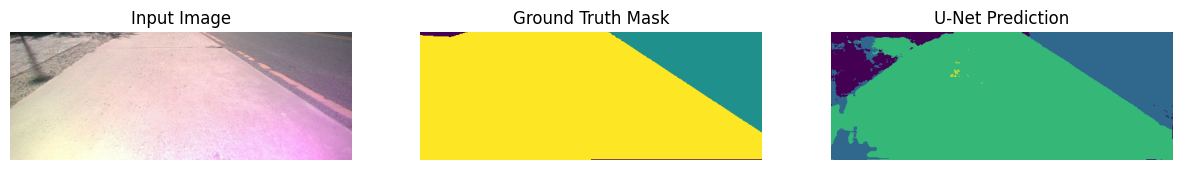

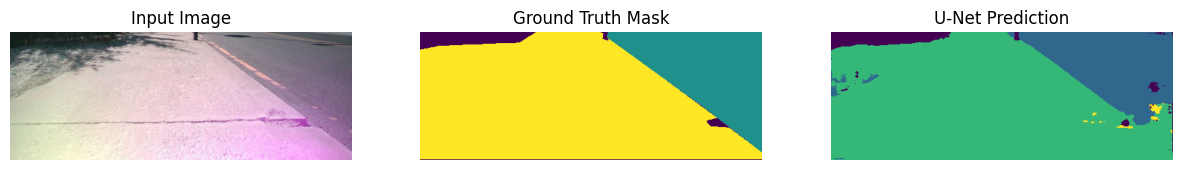

In [44]:
unet_model.eval()

images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = unet_model(images)
    preds = torch.argmax(outputs, dim=1).cpu()

images = images.cpu()

for i in range(3):
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(masks[i])
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(preds[i])
    plt.title("U-Net Prediction")
    plt.axis("off")

    plt.show()

In [45]:
import os

RESULTS_DIR = "/content/drive/MyDrive/AMR_Project_Results"
UNET_DIR = os.path.join(RESULTS_DIR, "UNet")

os.makedirs(UNET_DIR, exist_ok=True)

print("Results will be saved in:", UNET_DIR)

Results will be saved in: /content/drive/MyDrive/AMR_Project_Results/UNet


In [46]:
model_path = os.path.join(UNET_DIR, "unet_amr_segmentation.pth")

torch.save(unet_model.state_dict(), model_path)

print("U-Net model saved at:", model_path)

U-Net model saved at: /content/drive/MyDrive/AMR_Project_Results/UNet/unet_amr_segmentation.pth


In [47]:
import pandas as pd

unet_history_df = pd.DataFrame(unet_history)

history_path = os.path.join(UNET_DIR, "unet_training_history.csv")
unet_history_df.to_csv(history_path, index=False)

print("Training history saved at:", history_path)
unet_history_df

Training history saved at: /content/drive/MyDrive/AMR_Project_Results/UNet/unet_training_history.csv


,train_loss,val_loss,train_acc,val_acc,train_iou,val_iou
0,0.822130,0.707345,0.689714,0.725780,0.397620,0.457088
1,0.697269,0.615410,0.734170,0.767025,0.459719,0.494717
2,0.626379,0.560338,0.764230,0.786751,0.498727,0.519941
3,0.567393,0.503756,0.785635,0.810070,0.538615,0.554321
4,0.514163,0.467576,0.810026,0.827448,0.581423,0.576223
